In [1]:
import pandas as pd
from main import load_dataset
import seaborn as sns

df_all, pm = load_dataset("data/dataset.csv",
                      "data/codeforces/generated_tests",
                      "data/codeforces/data",
                      code_mod_ratio_threshold=0.6)
df_buggy = df_all[df_all["AcceptedAnchor"] != -1]

/home/vscode/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Axes: ylabel='verdict'>

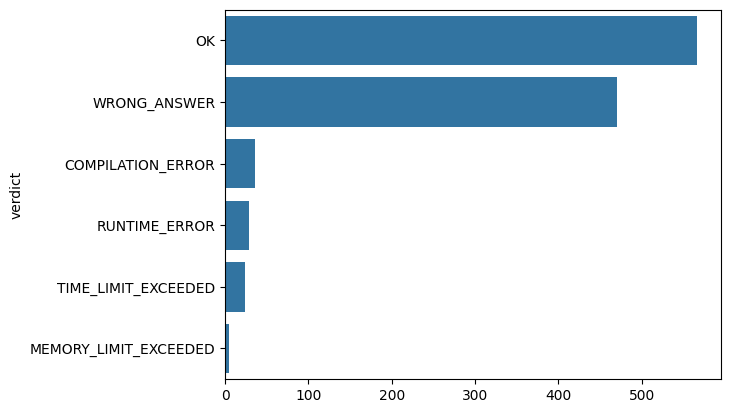

In [9]:
sns.barplot(y = df_all["verdict"].value_counts().index, 
            x = df_all["verdict"].value_counts().values, orient = 'y')

<Axes: xlabel='Number of buggy submissions per anchor', ylabel='Count'>

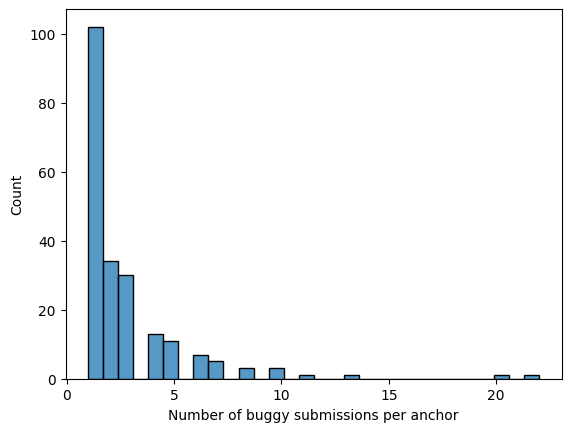

In [10]:
x = df_buggy.groupby('AcceptedAnchor').size().reset_index(name='Number of buggy submissions per anchor')
sns.histplot(x['Number of buggy submissions per anchor'])

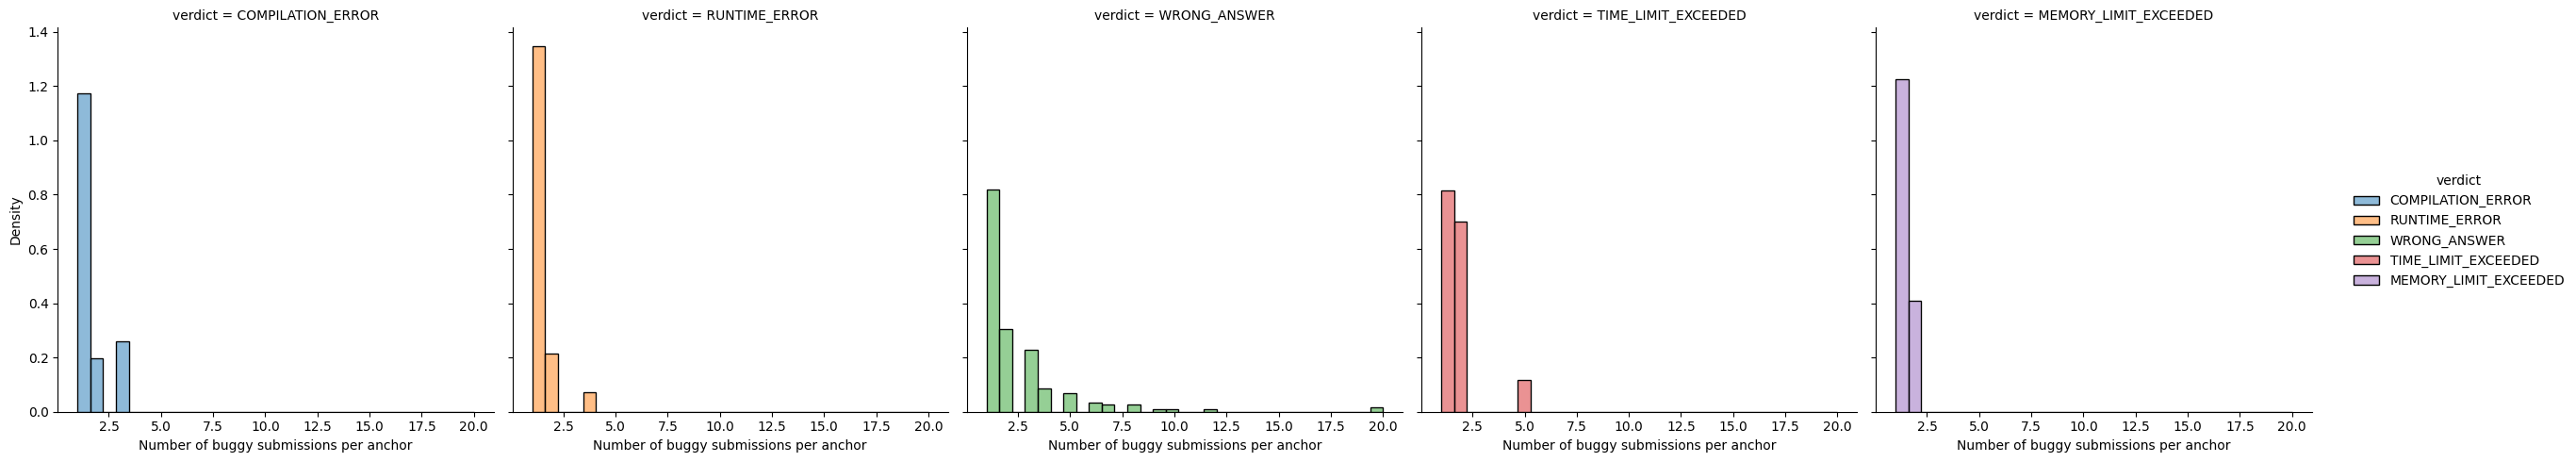

In [11]:
x = df_buggy.groupby(['AcceptedAnchor', 'verdict']).size().reset_index(name='Number of buggy submissions per anchor')

sns.displot(x, x = 'Number of buggy submissions per anchor', hue = 'verdict', col = 'verdict',stat = 'density', common_norm=False)

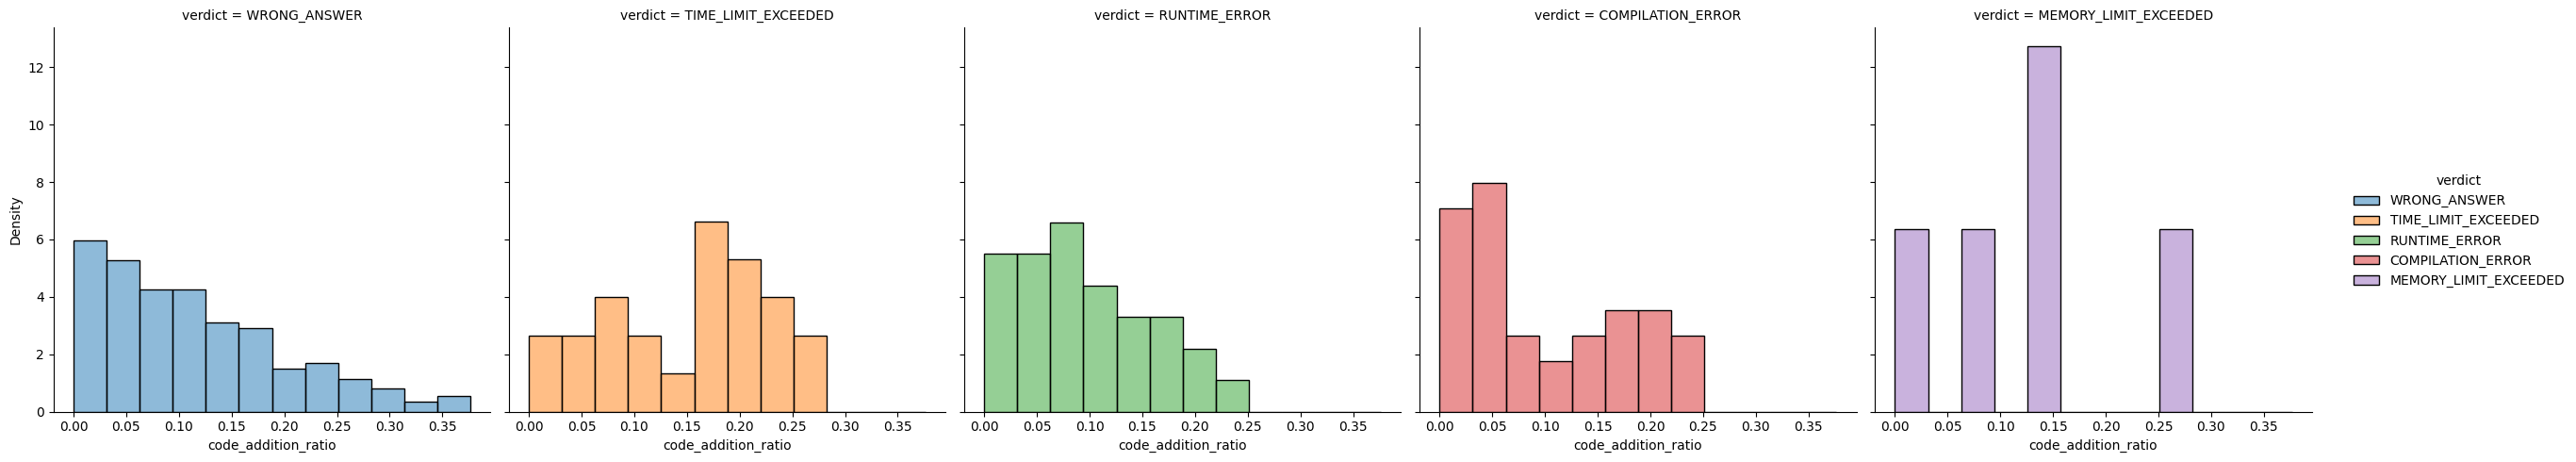

In [12]:
sns.displot(df_buggy, x = 'code_addition_ratio',hue = 'verdict', col = 'verdict', stat='density',common_norm=False)

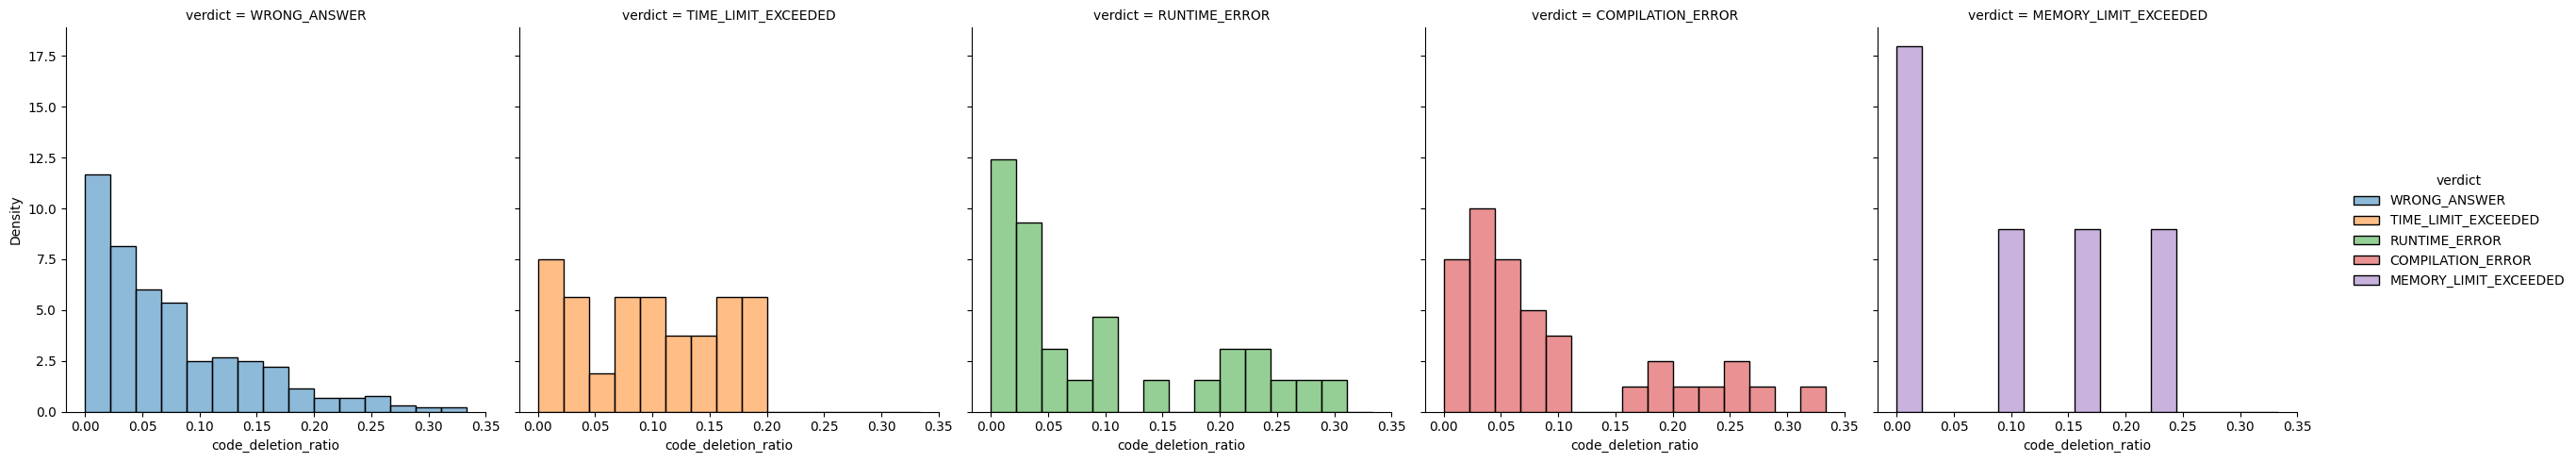

In [13]:
sns.displot(df_buggy, x = 'code_deletion_ratio',hue = 'verdict', col = 'verdict', stat='density',common_norm=False)

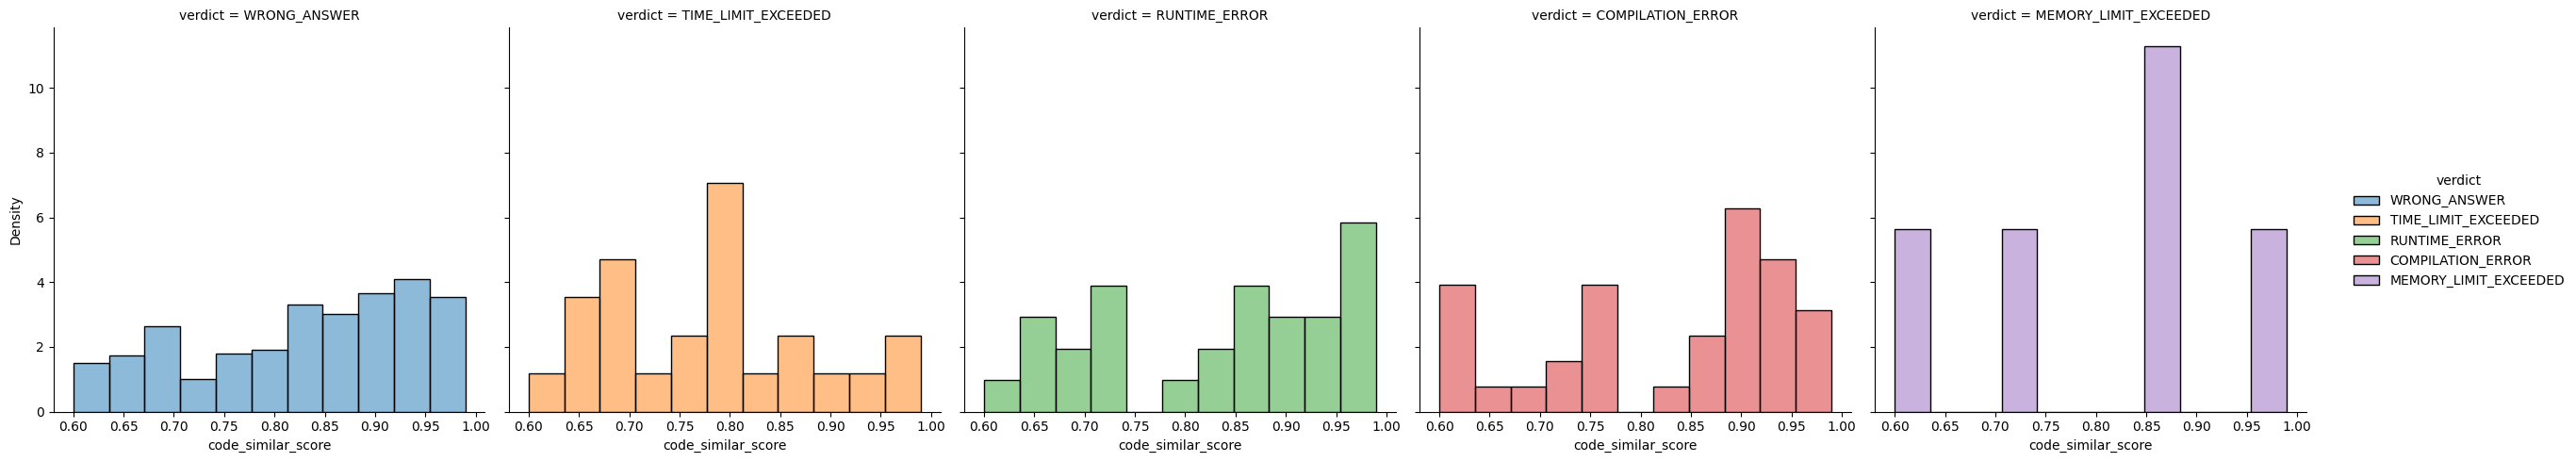

In [14]:
sns.displot(df_buggy, x = 'code_similar_score',hue = 'verdict', col = 'verdict', stat='density',common_norm=False)